In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


# Explicacion

Este caso se intentó hacer antes de evaluar los contenidos de la clase 5. La logica que se buscó fue:

1. Reescalar la imagen del logo para que siempre sea mas pequeña que la imagen a detectar
2. Utilizar canny, para quitar influencia de colores, fondos, etc, del logo
3. De forma iterativa, ir intentando detectar elementos en la imagen, hasta que la imagen a detectar sea del tamaño del logo

Esto unicamente nos funcionó en un caso, pero lo dejamos como muestra de la logica que intentamos aplicar

In [2]:
img_path = "images/coca_logo_1.png"

template_path = "template/pattern.png"

In [3]:
def detection_function(img_path:str, template_path:str, resize_percentaje, threshold):
    # Procesamos template

    template_img = cv.imread(template_path,0)
    template_edges = cv.Canny(template_img,100,200)


    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(template_img, cmap='gray')
    plt.subplot(1,2,2)
    plt.imshow(template_edges)
    plt.show()

    img_grayscale = cv.imread(img_path,0)
    image_edges = cv.Canny(img_grayscale,100,200)

    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(img_grayscale, cmap='gray')
    plt.subplot(1,2,2)
    plt.imshow(image_edges)
    plt.show()

    max_dim = np.argmax(template_edges.shape)

    scale_factor = ((img_grayscale.shape[max_dim]*resize_percentaje/100)/template_edges.shape[max_dim])

    # Resize the image (scaling down)
    resized_down_template = cv.resize(template_edges, None, fx=scale_factor, fy=scale_factor, interpolation=cv.INTER_AREA)


    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(template_edges, cmap='gray')
    plt.title("Template original")
    plt.subplot(1,2,2)
    plt.imshow(resized_down_template, cmap= 'gray')
    plt.title("Template reescalado")
    plt.show()
 
    current_image = image_edges.copy()

    edges = resized_down_template.copy()

    while (current_image.shape[0] > edges.shape[0]) and (current_image.shape[1] > edges.shape[1]):

        img_show = current_image.copy()

        method = eval('cv.TM_CCOEFF_NORMED')


        #current_edges = cv.Canny(current_image,100,200)

        res = cv.matchTemplate(current_image, edges, method)

        # Encontramos los valores máximos y mínimos
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

        w, h = edges.shape[::-1]

        threshold = 0.4

        loc = np.where( res >= threshold)
        for pt in zip(*loc[::-1]):
            cv.rectangle(img_show, pt, (pt[0] + w, pt[1] + h), (255,255,255), 2)

        if np.max(res) > threshold:
            print(f"Valor de confianza de deteccion: {np.max(res)}")

        # Graficamos el procesamiento y la salida
        #----------------------------------------
        plt.figure(figsize=(15, 5))
        # Resultado de coincidencia
        plt.subplot(121),plt.imshow(res,cmap = 'gray')
        plt.title('Matching Result'), plt.xticks([]), plt.yticks([])

        # Imagen original con recuadros
        plt.subplot(122),plt.imshow(img_show, cmap='gray')
        plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

        #plt.subplot(133),plt.imshow(current_edges,cmap='grey')
        #plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

        plt.suptitle(method)
        plt.show()
        
        print(current_image.shape)
        current_image = cv.resize(current_image, None, fx=0.80, fy=0.80, interpolation=cv.INTER_AREA).copy()
        #cv.imshow('Downscaled', current_image)
        #cv.waitKey(500)


In [4]:
resize_percentaje = 40

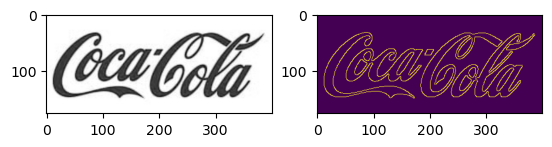

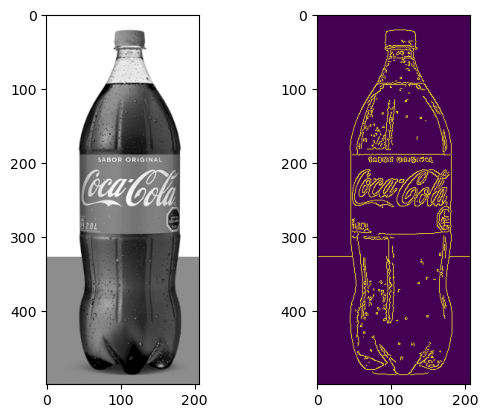

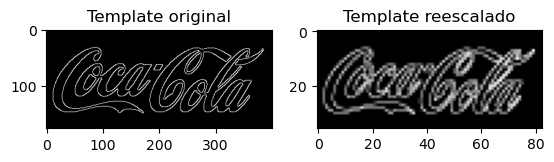

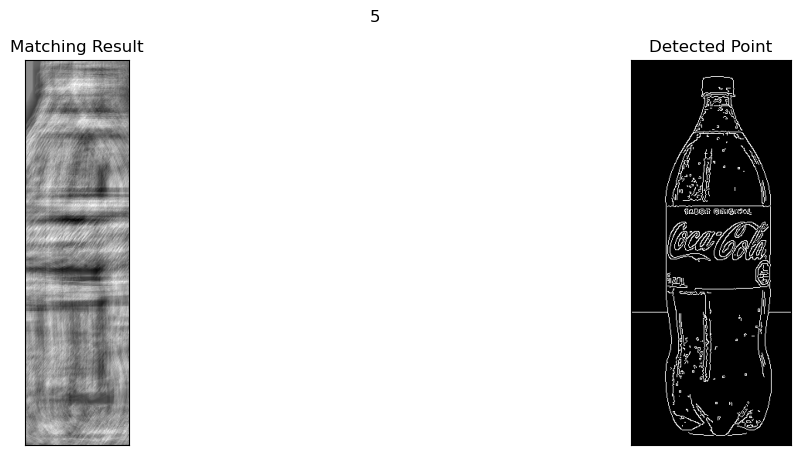

(500, 207)


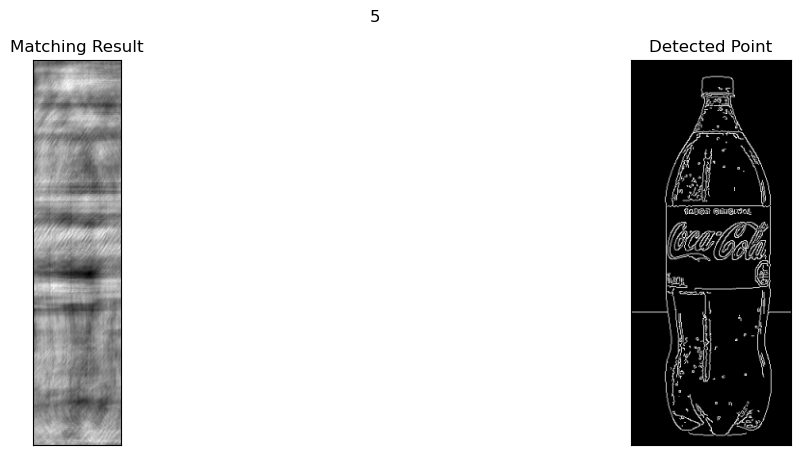

(400, 166)


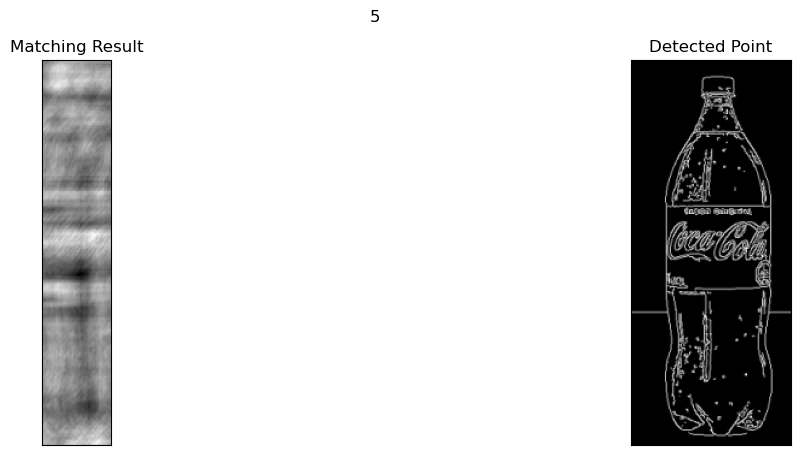

(320, 133)
Valor de confianza de deteccion: 0.5102475881576538


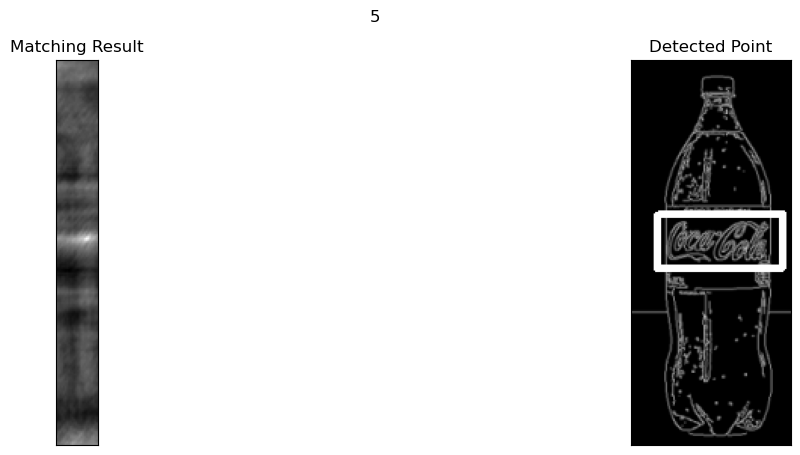

(256, 106)


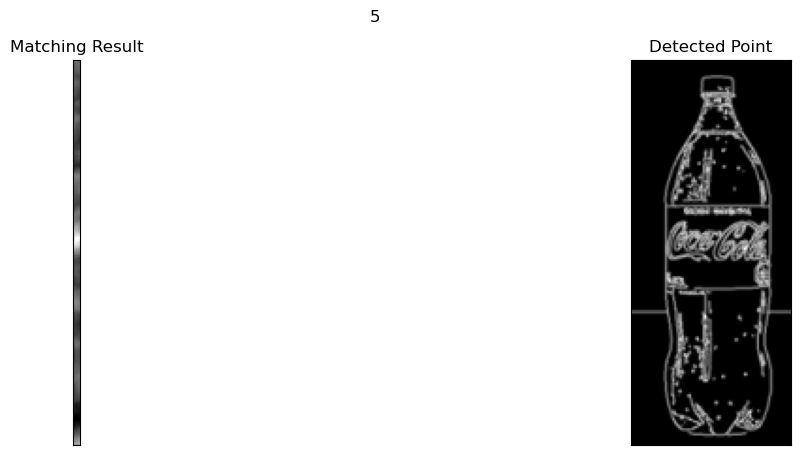

(205, 85)


In [5]:
detection_function(img_path=img_path, template_path=template_path, resize_percentaje=40, threshold=0.4)

Esto parece indicar resultados correctos, pero existe un problema. Si analizamos el valor de confianza encontramos que este es del 51%, no es muy alto. Si lo verificamos para otra imagen, tenemos:

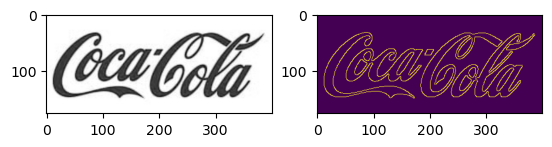

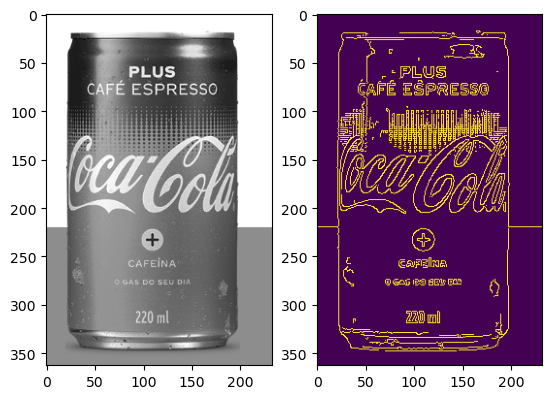

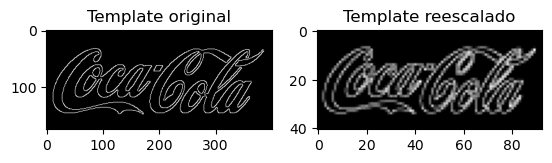

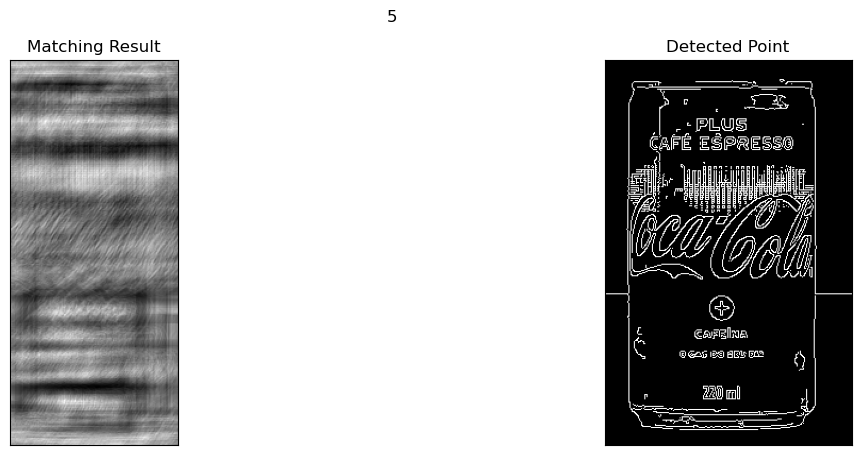

(363, 233)


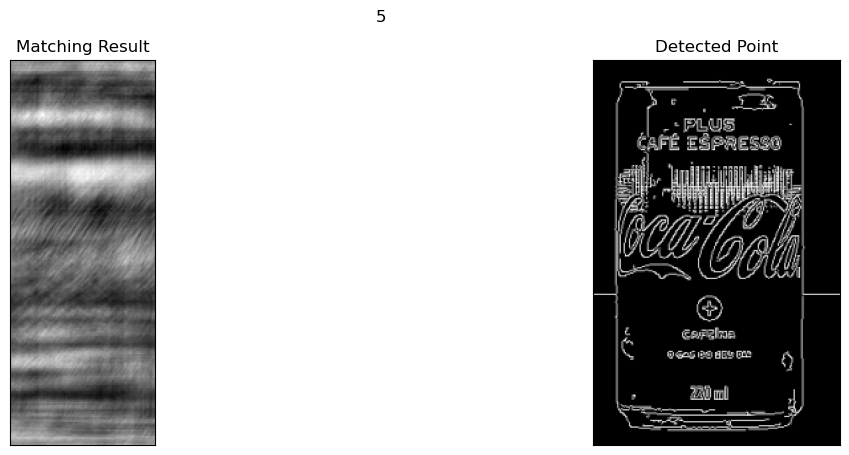

(290, 186)


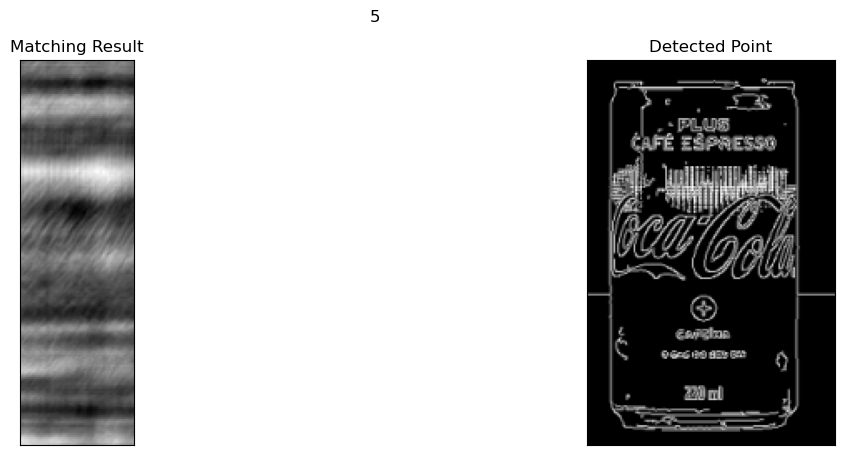

(232, 149)


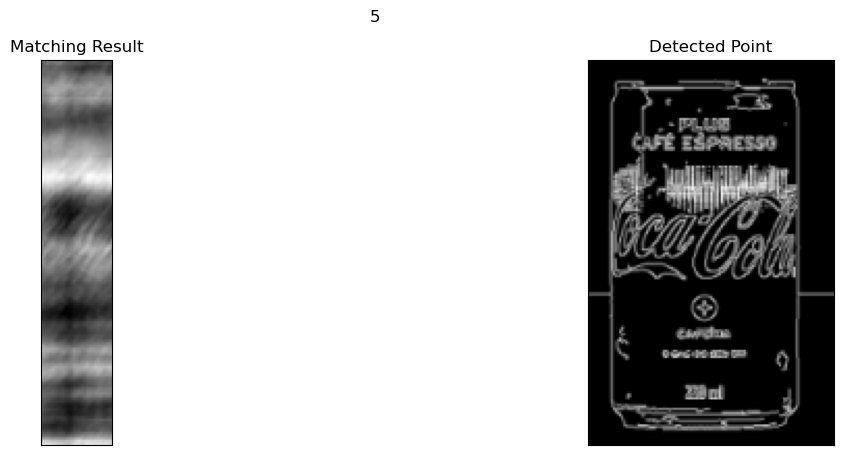

(186, 119)


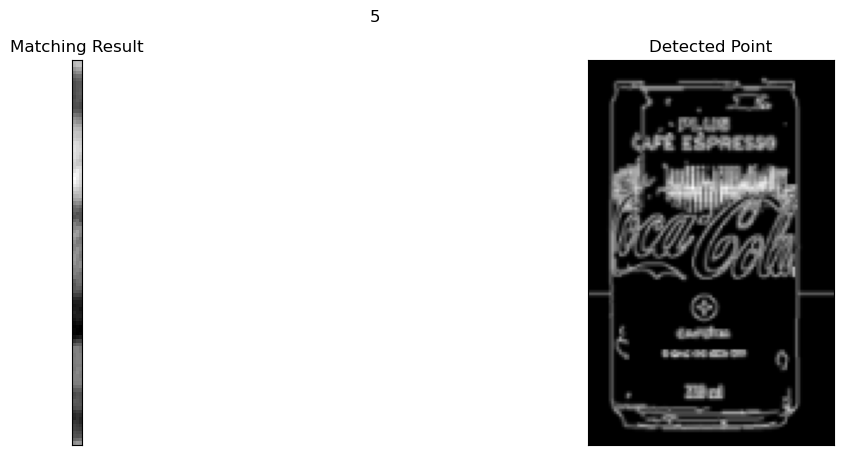

(149, 95)


In [6]:
detection_function(img_path="images/coca_logo_2.png", template_path=template_path, resize_percentaje=40, threshold=0.4)

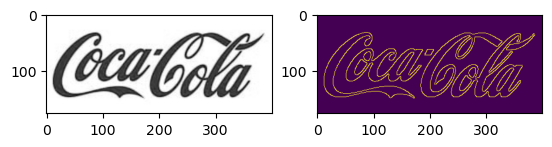

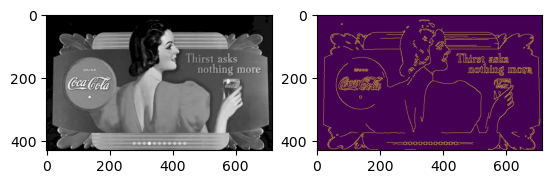

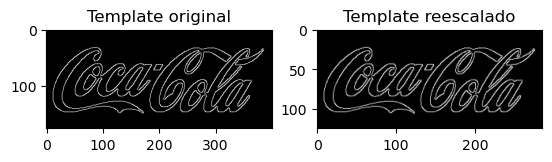

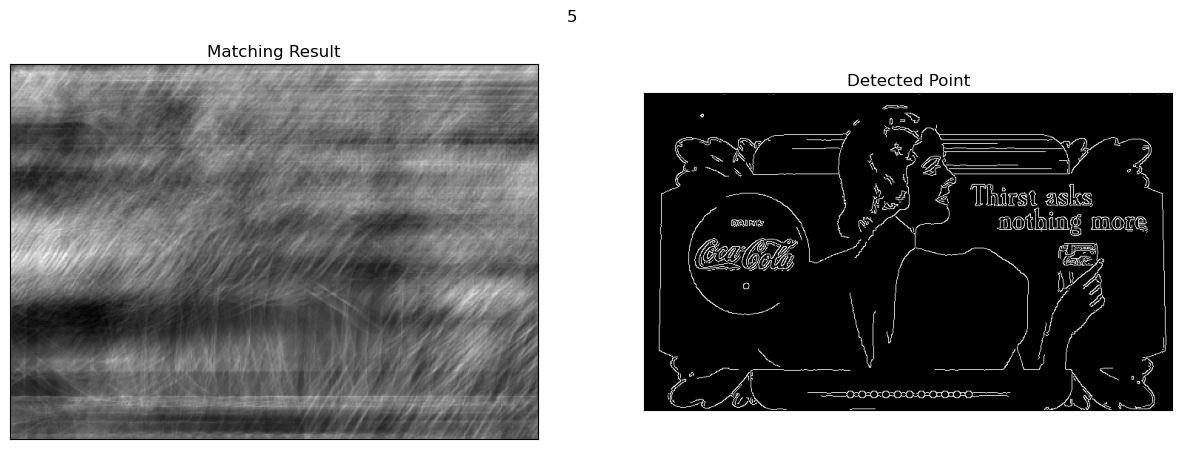

(429, 715)


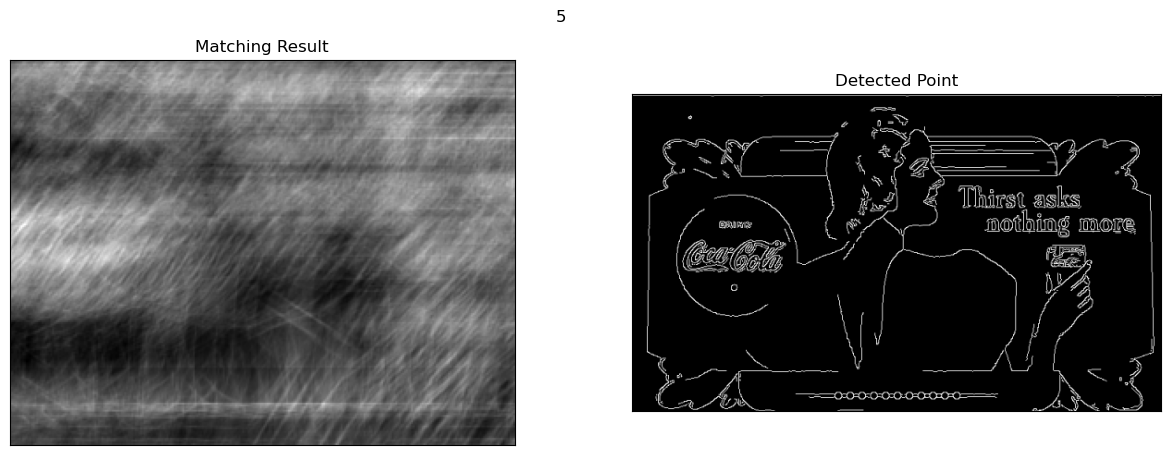

(343, 572)


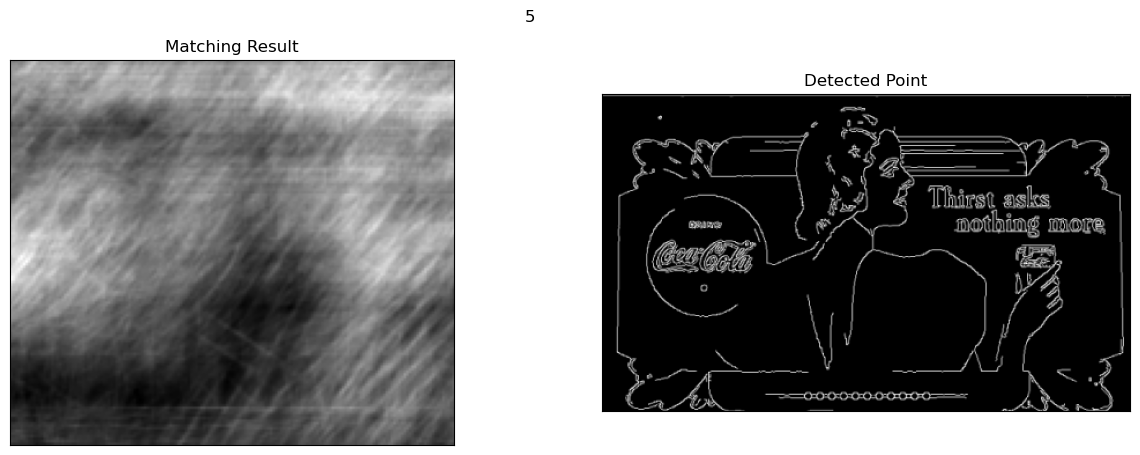

(274, 458)


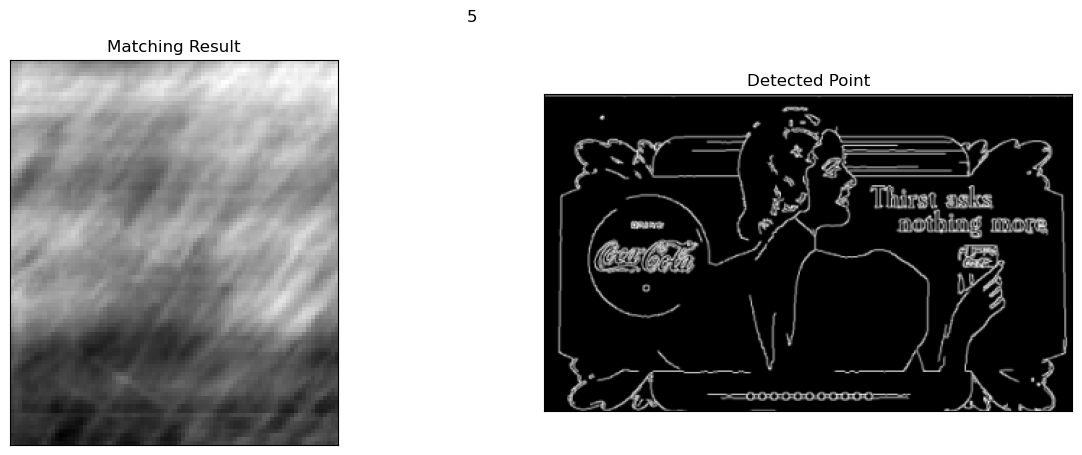

(219, 366)


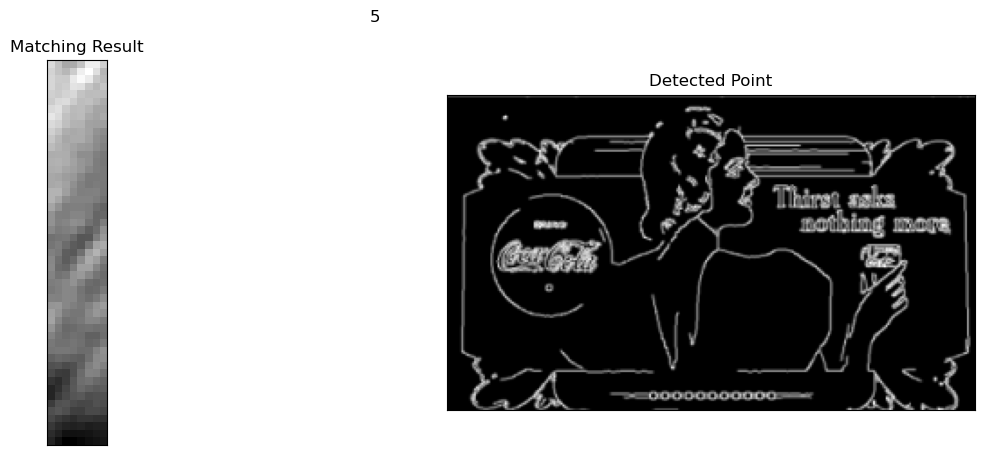

(175, 293)


In [7]:
detection_function(img_path="images/coca_retro_2.png", template_path=template_path, resize_percentaje=40, threshold=0.4)

In [36]:
#Si queremos que las imágenes sean mostradas en una ventana emergente quitar el inline
%matplotlib inline
#%matplotlib qt

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

In [57]:
def is_blurry(img, threshold=100.0, filename=None):
    laplacian = cv.Laplacian(img, cv.CV_64F)
    variance = laplacian.var()

    print(f"Laplacian variance for {filename}: {variance}")

    return variance < threshold

In [53]:
def unsharp_mask(image, kernel_size=(5, 5), sigma=1.0, amount=1.5, threshold=0):
    """
    Apply unsharp masking to sharpen an image.

    Parameters:
        image (numpy.ndarray): Input image to be sharpened.
        kernel_size (tuple): Size of the Gaussian kernel.
        sigma (float): Standard deviation for Gaussian kernel.
        amount (float): Strength of the sharpening effect.
        threshold (int): Minimum difference to apply sharpening.

    Returns:
        numpy.ndarray: Sharpened image.
    """
    # Apply Gaussian blur to the image
    blurred = cv.GaussianBlur(image, kernel_size, sigma)

    # Calculate the difference between the original and blurred image
    sharpened = float(amount) * (image - blurred) + image

    # Apply threshold to limit sharpening to significant differences
    if threshold > 0:
        low_contrast_mask = np.abs(image - blurred) < threshold
        np.copyto(sharpened, image, where=low_contrast_mask)

    # Clip the values to be in the valid range [0, 255] for uint8 images
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    return sharpened

In [97]:
# Cargamos la imagen a buscar
template = cv.imread('template/pattern.png')
template = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
template_edges = cv.Canny(template, threshold1=5, threshold2=200)

images = []
images_edges = []
for filename in os.listdir('images'):
    img = cv.imread(os.path.join('images', filename))
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    # if is_blurry(img, 100, filename):
    #     print(f"Image {filename} is blurry")
    img = unsharp_mask(img, kernel_size=(3, 3), sigma=1.0, amount=1, threshold=800)
    
    img_edges = cv.Canny(img, threshold1=5, threshold2=200)

    images.append(img)
    images_edges.append(img_edges)


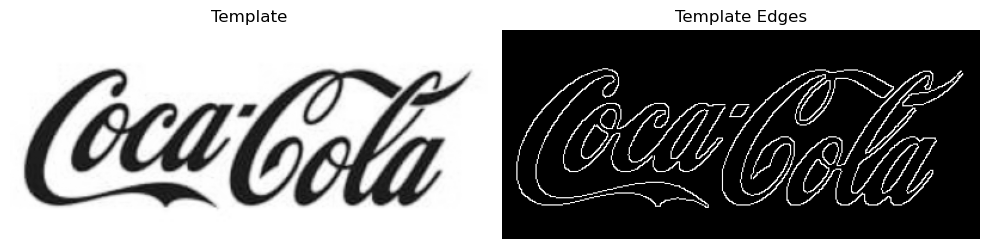

In [76]:
plt.figure(figsize=(10, 5))

# Plot the template
plt.subplot(1, 2, 1)
plt.imshow(template, cmap='gray')
plt.title('Template')
plt.axis('off')

# Plot the edges of the template
plt.subplot(1, 2, 2)
plt.imshow(template_edges, cmap='gray')
plt.title('Template Edges')
plt.axis('off')

plt.tight_layout()
plt.show()

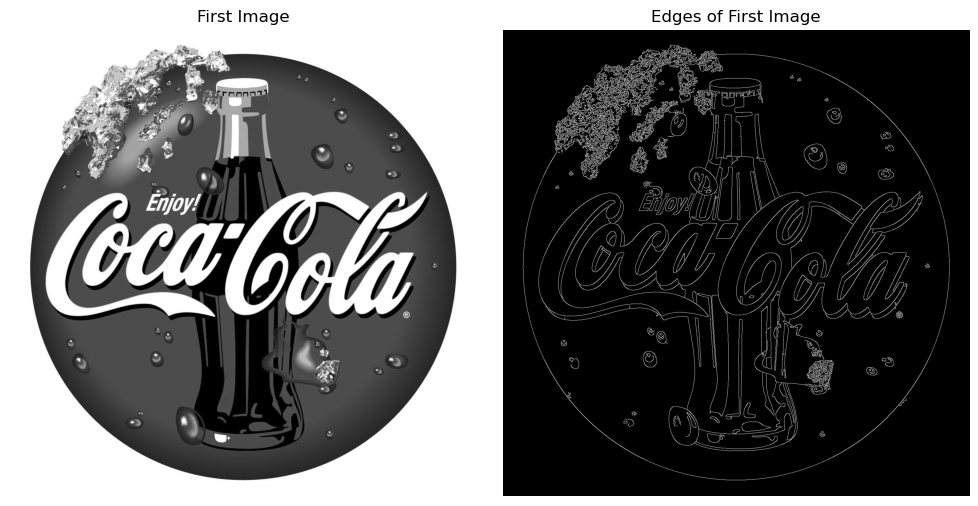

In [77]:
plt.figure(figsize=(10, 5))

# Plot the first image
plt.subplot(1, 2, 1)
plt.imshow(images[0], cmap='gray')
plt.title('First Image')
plt.axis('off')

# Plot the edges of the first image
plt.subplot(1, 2, 2)
plt.imshow(images_edges[0], cmap='gray')
plt.title('Edges of First Image')
plt.axis('off')

plt.tight_layout()
plt.show()

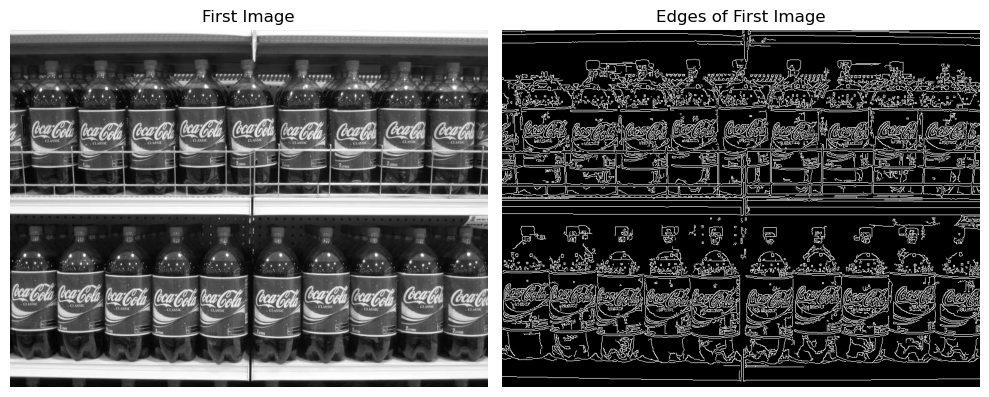

In [98]:
plt.figure(figsize=(10, 5))

# Plot the first image
plt.subplot(1, 2, 1)
plt.imshow(images[1], cmap='gray')
plt.title('First Image')
plt.axis('off')

# Plot the edges of the first image
plt.subplot(1, 2, 2)
plt.imshow(images_edges[1], cmap='gray')
plt.title('Edges of First Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [99]:
# Creamos el vector de características SIFT
sift = cv.SIFT_create(nfeatures=10000, contrastThreshold=0.0001, edgeThreshold=0.0001)

# Y buscamos según el algoritmo...
kp, des = sift.detectAndCompute(template_edges, None)

images_kp_des = {}

for i, img in enumerate(images_edges):
    kp_i, des_i = sift.detectAndCompute(img, None)
    images_kp_des[i] = (kp_i, des_i)

print(len(kp))
print(len(images_kp_des[0][0]))

234
3874


In [27]:
# Inicializamos el detector ORB
orb = cv.ORB_create(nfeatures=3000, patchSize=2000)

kp, des = orb.detectAndCompute(template_edges, None)

images_kp_des = {}

for i, img in enumerate(images_edges):
    kp_i, des_i = orb.detectAndCompute(img, None)
    images_kp_des[i] = (kp_i, des_i)

print(len(kp))
print(len(images_kp_des[0][0]))

1635
3000


In [103]:
def flann_match(kp1, kp2, des1, des2, img1, img2):

    # des1 = np.float32(des1)
    # des2 = np.float32(des2)
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    search_params = dict(checks = 2000000)
    flann = cv.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1,des2,k=2)

    good = []
    for m,n in matches:
        if m.distance < 0.9*n.distance:
            good.append(m)
    # print(len(good))


    MIN_MATCH_COUNT = 8

    if len(good) >= MIN_MATCH_COUNT:
        src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
        dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
        matchesMask = mask.ravel().tolist()
        h,w = img1.shape
        pts = np.float32([ [0,0],[0,h],[w,h],[w,0] ]).reshape(-1,1,2)
        dst = cv.perspectiveTransform(pts, M)
        img3 = cv.polylines(img2, [np.int32(dst)], True, 255, 3, cv.LINE_AA)
        # print(mask)
        return good, matchesMask, img3
    else:
        print( "No se encontraron suficientes coincidencias - {}/{}".format(len(good), MIN_MATCH_COUNT) )
        matchesMask = None

In [28]:
def brute_force_match(kp1, kp2, des1, des2, img1, img2):
    bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)

    # Coincidimos descriptores.
    matches = bf.match(des1, des2)

    # Los ordenamos según distancia
    matches = sorted(matches, key = lambda x:x.distance)

    img3 = cv.drawMatches(img1,kp1,img2,kp2,matches[:30],None,flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.imshow(img3),plt.show()

In [106]:
matches = {}
for i, (kp_i, des_i) in images_kp_des.items():
    try:
        good, mask, img_matches = flann_match(kp, kp_i, des, des_i, template_edges, images_edges[i])
        matches[i] = (good, mask, img_matches)
    except Exception as e:
        print(f"Error processing image {i}: {e}")

In [ ]:
matches = {}
for i, (kp_i, des_i) in images_kp_des.items():
    try:
        img_matches = brute_force_match(kp, kp_i, des, des_i, template, images_edges[i])
        matches[i] = img_matches
    except Exception as e:
        print(f"Error processing image {i}: {e}")

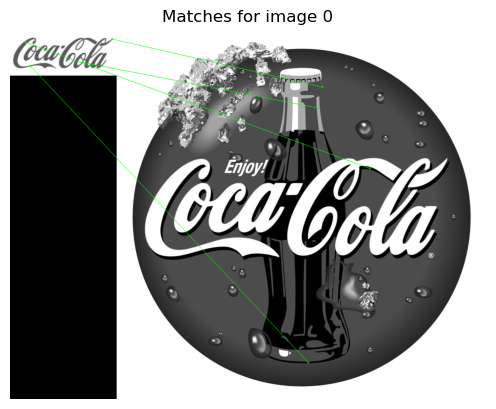

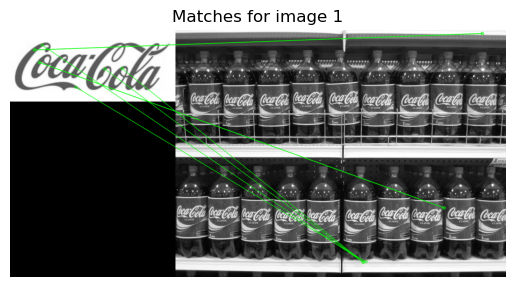

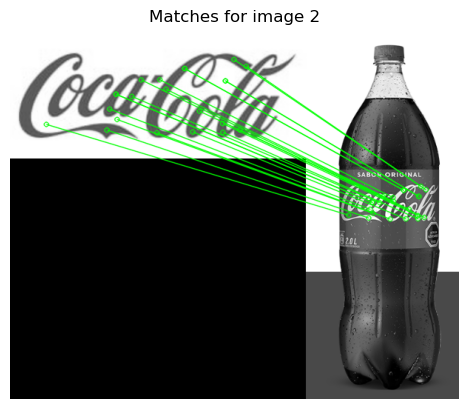

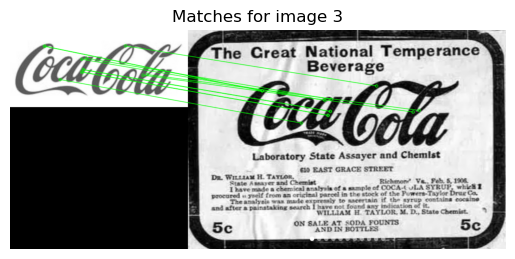

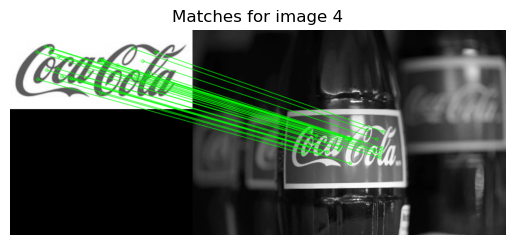

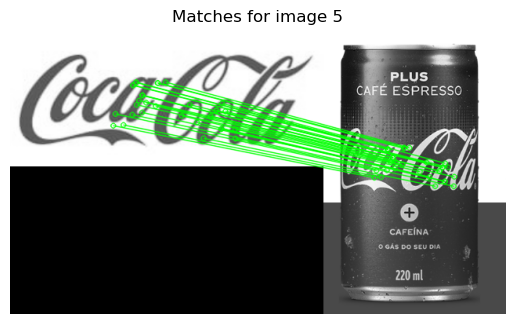

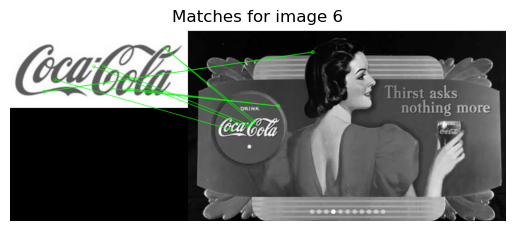

In [107]:
for i, (good, mask, img_matches) in matches.items():
    draw_params = dict(matchColor = (0,255,0), # dibujar coincidencias en verde
                       singlePointColor = None,
                       matchesMask = mask, # dibujar solo inliers
                       flags = 2)
    img_4 = cv.drawMatches(template, kp, images[i], images_kp_des[i][0], good, None, **draw_params)
    plt.imshow(img_4, 'gray')
    plt.title(f'Matches for image {i}')
    plt.axis('off')
    plt.show()

Analizando los resultados, encontramos que si bien, la logica parecía prometedora, esta era muy poco robusta, ante cambios en la imagen, los resultados variaban de manera notable, lo que lo hacía un metodo muy poco fiable. Ante cambios en la imagen, debíamos modificar los parámetros de escalado y threshhold, lo cual no era ideal para una aplicación real.